In [78]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

model = tf.keras.models.load_model("intel_nn_model_93_9.h5")

# บังคับ build graph
dummy = np.zeros((1,224,224,3))
model(dummy)
model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step


array([[0.4906211 , 0.19602902, 0.05974662, 0.08367483, 0.03703595,
        0.1328925 ]], dtype=float32)

In [79]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # ดึง base model
    base_model = model.get_layer("mobilenetv2_1.00_224")

    # ดึง classifier part
    x = base_model.output
    x = model.layers[1](x)
    x = model.layers[2](x)
    x = model.layers[3](x)
    predictions = model.layers[4](x)

    # model ใหม่
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            predictions
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, preds = grad_model(img_array)

        class_idx = tf.argmax(preds[0])

        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

In [80]:
img_path = r"C:\Users\podja\OneDrive\Desktop\project-ai\Intel\predict\p1.jpg"

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [81]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,728 (9.24 MB)

 Trainable params: 1,846,278 (7.04 MB)

 Non-trainable params: 576,448 (2.20 MB)

 Optimizer params: 2 (12.00 B)

In [82]:
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    "Conv_1"
)

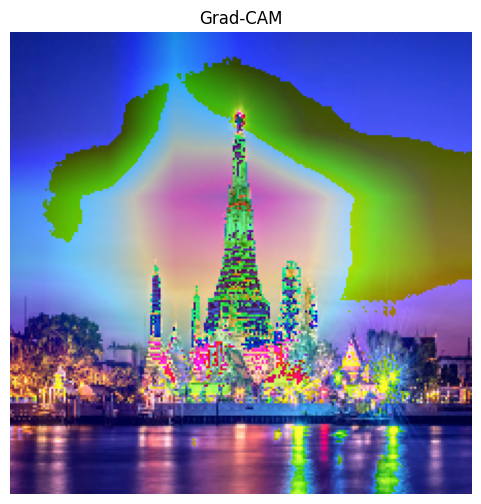

In [83]:
img_original = cv2.imread(img_path)
img_original = cv2.resize(img_original, (224,224))

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img_original

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Grad-CAM")
plt.show()